In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler ,LabelEncoder,OneHotEncoder
from sklearn.tree import DecisionTreeClassifier 
import seaborn as sns 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [5]:
df=pd.read_csv("employee_data.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0.0,sales,low
1,0.80,0.86,5,262,6,0,1,0.0,sales,medium
2,0.11,0.88,7,272,4,0,1,0.0,sales,medium
3,0.72,0.87,5,223,5,0,1,0.0,sales,low
4,0.37,0.52,2,159,3,0,1,0.0,sales,low


In [6]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years
count,11582.000000,11582.000000,11582.000000,11582.000000,11582.000000,11582.000000,11582.000000,11581.000000
mean,0.628308,0.716608,3.802884,200.523053,3.305215,0.152651,0.172682,0.013816
std,0.241985,0.168828,1.169843,48.839268,1.209369,0.359666,0.377988,0.116731
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [7]:
df["salary"].value_counts()

salary
low       5583
medium    5097
high       901
Name: count, dtype: int64

In [8]:
df["department"].value_counts()

department
sales          3092
technical      2227
support        1790
IT              935
RandD           689
product_mng     638
marketing       633
accounting      611
hr              601
management      365
Name: count, dtype: int64

In [9]:
label=LabelEncoder()
col=["department","salary"]
for i in col :
    df[i]=label.fit_transform(df[i])
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0.0,7,1
1,0.80,0.86,5,262,6,0,1,0.0,7,2
2,0.11,0.88,7,272,4,0,1,0.0,7,2
3,0.72,0.87,5,223,5,0,1,0.0,7,1
4,0.37,0.52,2,159,3,0,1,0.0,7,1
...,...,...,...,...,...,...,...,...,...,...
11577,0.55,0.78,4,261,3,0,0,0.0,4,0
11578,0.76,0.56,5,222,10,0,0,0.0,4,0
11579,0.53,0.99,3,223,10,0,0,0.0,5,1
11580,0.51,0.86,3,182,10,0,0,0.0,7,1


In [10]:
df.isnull().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
quit                     0
promotion_last_5years    1
department               0
salary                   0
dtype: int64

In [11]:
df.dropna(axis=0,inplace=True)

In [12]:
df.duplicated().sum()

np.int64(9)

In [13]:
df.drop_duplicates()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0.0,7,1
1,0.80,0.86,5,262,6,0,1,0.0,7,2
2,0.11,0.88,7,272,4,0,1,0.0,7,2
3,0.72,0.87,5,223,5,0,1,0.0,7,1
4,0.37,0.52,2,159,3,0,1,0.0,7,1
...,...,...,...,...,...,...,...,...,...,...
11576,0.97,0.51,5,215,7,0,0,0.0,4,0
11577,0.55,0.78,4,261,3,0,0,0.0,4,0
11578,0.76,0.56,5,222,10,0,0,0.0,4,0
11579,0.53,0.99,3,223,10,0,0,0.0,5,1


In [14]:
scaler=StandardScaler()
df["average_montly_hours"]=scaler.fit_transform(df[["average_montly_hours"]])

In [15]:
corr=df.corr()


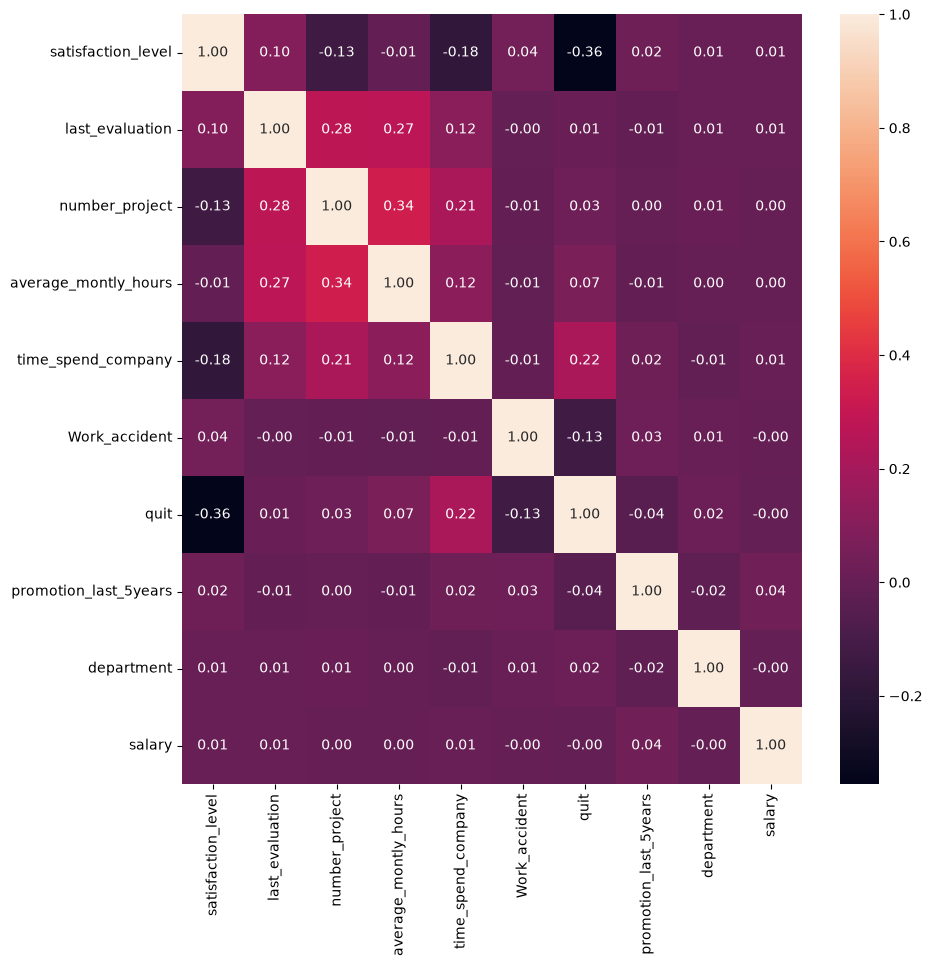

In [16]:
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,fmt="0.2f")
plt.show()

In [17]:
df.groupby(df["quit"])["satisfaction_level"].mean()

quit
0    0.667632
1    0.439955
Name: satisfaction_level, dtype: float64

In [18]:
df["quit"].value_counts(normalize=True)

quit
0    0.827303
1    0.172697
Name: proportion, dtype: float64

split data

In [19]:
x=df.drop("quit",axis=1)
y=df["quit"]
smot=SMOTE(random_state=42)
x_res,y_res=smot.fit_resample(x,y)
x,y=x_res,y_res

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.2,random_state=42)

Decision Tree 

In [21]:
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

TRAINING ACCURCY

In [26]:
y_pred_train=model.predict(x_train)
accuracy_train=accuracy_score(y_train,y_pred_train)
accuracy_train*100

100.0

TEST ACCURACY

In [25]:
y_pred=model.predict(x_test)
accu=accuracy_score(y_test,y_pred)
accu*100

94.39660795825179

In [24]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      7677
           1       0.94      0.95      0.94      7653

    accuracy                           0.94     15330
   macro avg       0.94      0.94      0.94     15330
weighted avg       0.94      0.94      0.94     15330

[[7236  441]
 [ 418 7235]]


<Axes: >

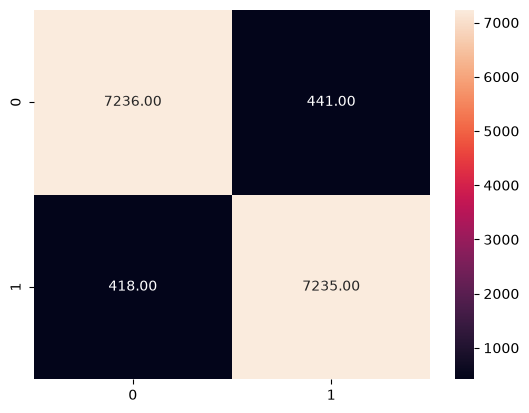

In [29]:
sns.heatmap(confusion_matrix(y_test,y_pred),fmt="0.2f",annot=True)